In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [44]:
# Load dataset
df = pd.read_csv("Student Performance Data.csv")

# Preview
df.head()

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Motivation_Level,Teacher_Quality,School_Type,Internet_Access,Family_Income,Parental_Involvement,Parental_Education_Level,Distance_from_Home,Physical_Activity,Peer_Influence,Access_to_Resources,Extracurricular_Activities,Health,Study_Environment,Exam_Score
0,7,53,58,3,8,high,Poor,Public,No,Medium,High,NaN,28.0,1,Positive,Low,Yes,1,Average,98
1,4,53,99,1,8,LOW,Average,Private,Yes,Low,High,School,NaN,2,Neutral,Low,Yes,2,Good,98
2,60,55,88,2,9,Medium,Poor,Private,No,Low,Medium,School,NaN,3,Neutral,Low,No,4,Poor,73
3,8,46,93,2,20,High,Good,Private,Yes,Medium,Low,Graduate,3.0,3,Negative,Low,No,2,Poor,35
4,5,71,53,0,5,High,Good,Private,No,Medium,Medium,Postgraduate,20.0,4,Positive,High,Yes,1,Poor,85


In [48]:
import numpy as np

# Create realistic score
df['Exam_Score'] = (
    df['Hours_Studied'] * 1.5 +        # moderate effect
    df['Attendance'] * 0.3 +           # important factor
    df['Previous_Scores'] * 0.4 +      # strong factor
    df['Sleep_Hours'] * 1 +            # slight effect
    np.random.randint(0, 10, size=len(df))   # natural variation
)

# Scale to realistic exam range (40–95)
df['Exam_Score'] = 40 + (
    (df['Exam_Score'] - df['Exam_Score'].min()) /
    (df['Exam_Score'].max() - df['Exam_Score'].min())
) * 55

# Round values
df['Exam_Score'] = df['Exam_Score'].round(1)

# Save dataset (overwrite)
df.to_csv("final_cleaning_dataset_6608x20.csv", index=False)

# Save (overwrite dataset)
df.to_csv("Student Performance Data1.csv", index=False)

In [49]:
df = pd.read_csv("Student Performance Data1.csv")

In [50]:
# Shape of dataset
df.shape

# Column names
df.columns

# Data types and info
df.info()

# Statistical summary
df.describe()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6608 entries, 0 to 6607
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6608 non-null   int64  
 1   Attendance                  6608 non-null   int64  
 2   Previous_Scores             6608 non-null   int64  
 3   Tutoring_Sessions           6608 non-null   int64  
 4   Sleep_Hours                 6608 non-null   int64  
 5   Motivation_Level            6608 non-null   object 
 6   Teacher_Quality             5947 non-null   object 
 7   School_Type                 6608 non-null   object 
 8   Internet_Access             6608 non-null   object 
 9   Family_Income               6608 non-null   object 
 10  Parental_Involvement        6608 non-null   object 
 11  Parental_Education_Level    5947 non-null   object 
 12  Distance_from_Home          5947 non-null   float64
 13  Physical_Activity           6608 

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Motivation_Level,Teacher_Quality,School_Type,Internet_Access,Family_Income,Parental_Involvement,Parental_Education_Level,Distance_from_Home,Physical_Activity,Peer_Influence,Access_to_Resources,Extracurricular_Activities,Health,Study_Environment,Exam_Score
0,7,53,58,3,8,high,Poor,Public,No,Medium,High,NaN,28.0,1,Positive,Low,Yes,1,Average,51.4
1,4,53,99,1,8,LOW,Average,Private,Yes,Low,High,School,NaN,2,Neutral,Low,Yes,2,Good,57.0
2,60,55,88,2,9,Medium,Poor,Private,No,Low,Medium,School,NaN,3,Neutral,Low,No,4,Poor,95.0
3,8,46,93,2,20,High,Good,Private,Yes,Medium,Low,Graduate,3.0,3,Negative,Low,No,2,Poor,63.6
4,5,71,53,0,5,High,Good,Private,No,Medium,Medium,Postgraduate,20.0,4,Positive,High,Yes,1,Poor,51.6


In [51]:
# Unique values in each column
df.nunique()
# Check categorical columns manually
print(df['Motivation_Level'].unique())
print(df['Teacher_Quality'].unique())
print(df['School_Type'].unique())


['high' 'LOW' 'Medium' 'High' 'Low']
['Poor' 'Average' 'Good' nan]
['Public' 'Private']


In [52]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print(df.duplicated().sum())

Hours_Studied                   0
Attendance                      0
Previous_Scores                 0
Tutoring_Sessions               0
Sleep_Hours                     0
Motivation_Level                0
Teacher_Quality               661
School_Type                     0
Internet_Access                 0
Family_Income                   0
Parental_Involvement            0
Parental_Education_Level      661
Distance_from_Home            661
Physical_Activity               0
Peer_Influence                  0
Access_to_Resources             0
Extracurricular_Activities      0
Health                          0
Study_Environment               0
Exam_Score                      0
dtype: int64
0


In [53]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])

In [54]:
df

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Motivation_Level,Teacher_Quality,School_Type,Internet_Access,Family_Income,Parental_Involvement,Parental_Education_Level,Distance_from_Home,Physical_Activity,Peer_Influence,Access_to_Resources,Extracurricular_Activities,Health,Study_Environment,Exam_Score
0,7,53,58,3,8,high,Poor,Public,No,Medium,High,NaN,28.0,1,Positive,Low,Yes,1,Average,51.4
1,4,53,99,1,8,LOW,Average,Private,Yes,Low,High,School,NaN,2,Neutral,Low,Yes,2,Good,57.0
2,60,55,88,2,9,Medium,Poor,Private,No,Low,Medium,School,NaN,3,Neutral,Low,No,4,Poor,95.0
3,8,46,93,2,20,High,Good,Private,Yes,Medium,Low,Graduate,3.0,3,Negative,Low,No,2,Poor,63.6
4,5,71,53,0,5,High,Good,Private,No,Medium,Medium,Postgraduate,20.0,4,Positive,High,Yes,1,Poor,51.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6603,7,45,81,2,4,Medium,Average,Public,Yes,Medium,High,Graduate,3.0,1,Positive,Medium,No,3,Average,52.2
6604,5,58,79,2,7,Low,Average,Private,No,Low,Low,School,16.0,0,Neutral,Medium,Yes,5,Average,56.1
6605,7,82,63,1,7,Medium,Average,Public,Yes,Medium,High,School,15.0,2,Negative,Low,No,4,Average,57.7
6606,2,80,65,4,7,Medium,Average,Private,Yes,Low,Low,School,5.0,2,Negative,Medium,No,1,Good,52.9


In [55]:
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(
    df['Parental_Education_Level'].mode()[0])

In [56]:
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(
    df['Distance_from_Home'].median()
)

In [57]:
df['Motivation_Level'].unique()

array(['high', 'LOW', 'Medium', 'High', 'Low'], dtype=object)

In [58]:
df['Motivation_Level'] = df['Motivation_Level'].str.lower()
df['Motivation_Level'] = df['Motivation_Level'].str.capitalize()

In [59]:
df['Motivation_Level']

0         High
1          Low
2       Medium
3         High
4         High
         ...  
6603    Medium
6604       Low
6605    Medium
6606    Medium
6607    Medium
Name: Motivation_Level, Length: 6608, dtype: object

In [60]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions',
       'Sleep_Hours', 'Distance_from_Home', 'Physical_Activity', 'Health',
       'Exam_Score'],
      dtype='object')

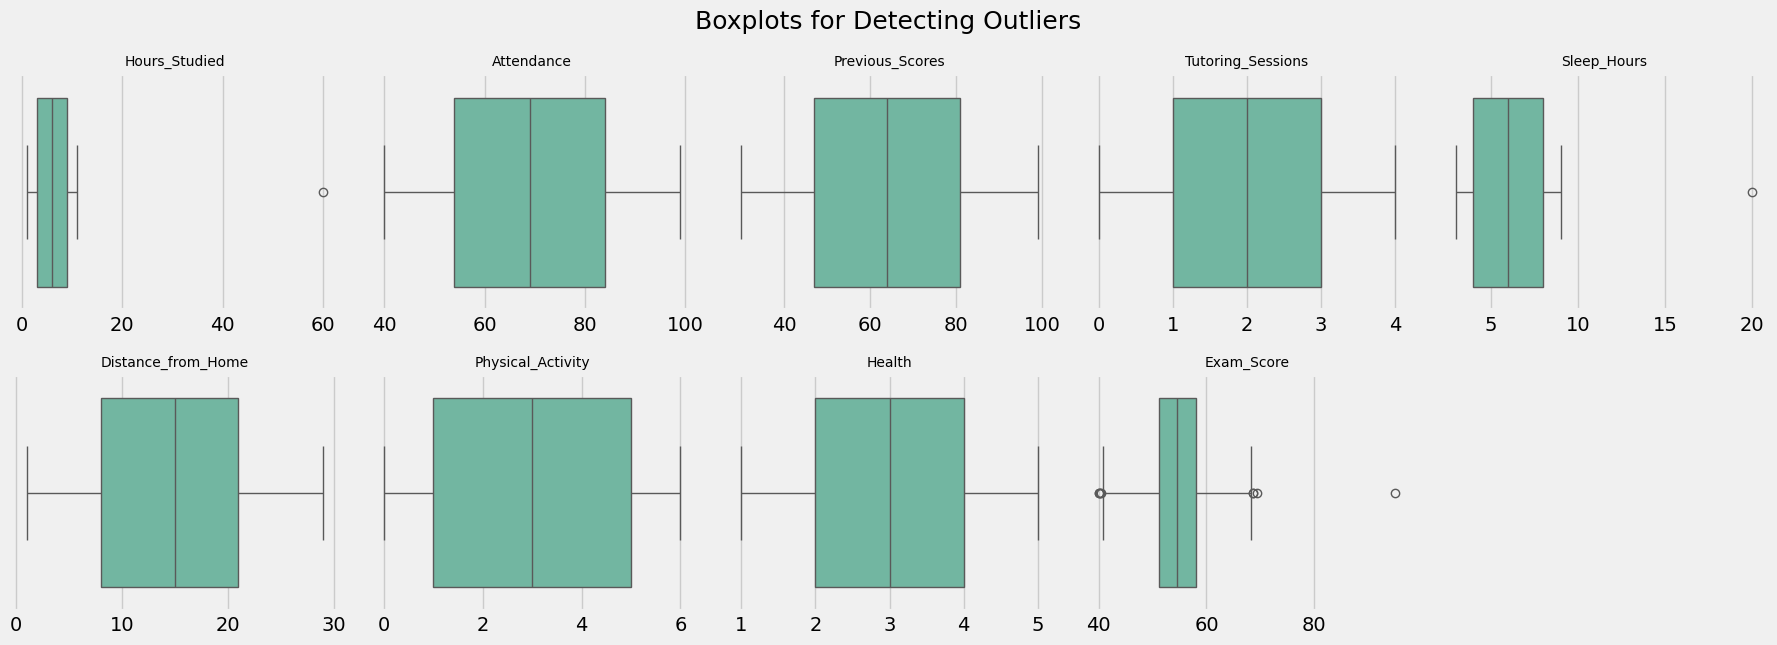

In [61]:
# Set figure size
plt.figure(figsize=(18, 12))

# Loop and create subplots
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 5, i)   # adjust grid based on columns
    sns.boxplot(x=df[col])
    
    plt.title(col, fontsize=10)
    plt.xlabel("")
    
# Adjust layout
plt.tight_layout()

# Add main title
plt.suptitle("Boxplots for Detecting Outliers", fontsize=18, y=1.02)
plt.savefig('boxplot.png')
plt.show()

In [62]:
Q1 = df['Hours_Studied'].quantile(0.25)
Q3 = df['Hours_Studied'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['Hours_Studied'] = np.where(df['Hours_Studied'] > upper, upper, df['Hours_Studied'])
df['Hours_Studied'] = np.where(df['Hours_Studied'] < lower, lower, df['Hours_Studied'])

In [63]:
Q1 = df['Sleep_Hours'].quantile(0.25)
Q3 = df['Sleep_Hours'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['Sleep_Hours'] = np.where(df['Sleep_Hours'] > upper, upper, df['Sleep_Hours'])
df['Sleep_Hours'] = np.where(df['Sleep_Hours'] < lower, lower, df['Sleep_Hours'])

In [64]:
plt.style.use('fivethirtyeight')   # modern style
sns.set_palette('Set2')   

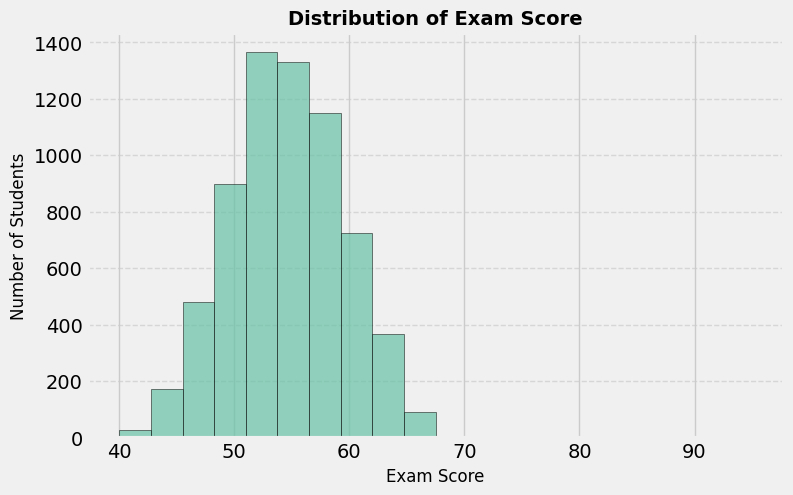

In [65]:
plt.figure(figsize=(8,5))

plt.hist(df['Exam_Score'], bins=20, edgecolor='black', alpha=0.7)

plt.title("Distribution of Exam Score", fontsize=14, fontweight='bold')
plt.xlabel("Exam Score", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

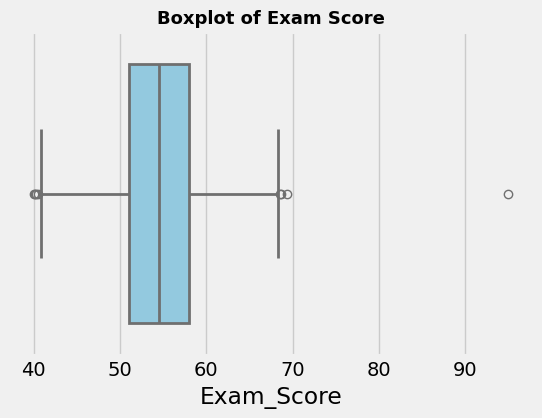

In [66]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['Exam_Score'], color='skyblue', linewidth=2)

plt.title("Boxplot of Exam Score", fontsize=13, fontweight='bold')

plt.show()

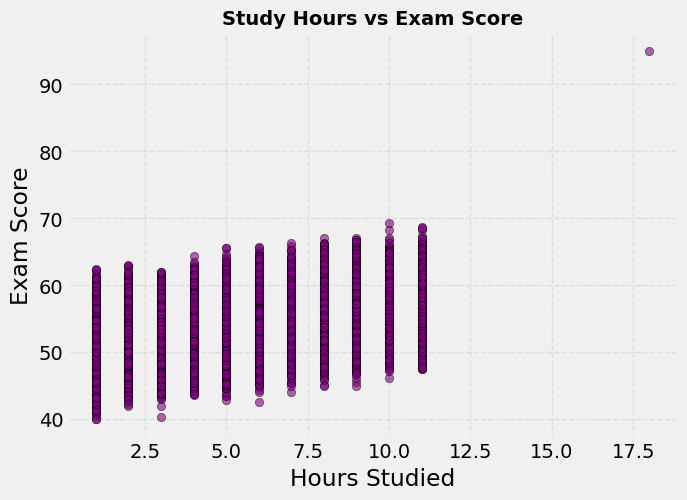

In [67]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Hours_Studied'], 
    df['Exam_Score'], 
    color='purple', 
    alpha=0.6, 
    edgecolor='black'
)

plt.title("Study Hours vs Exam Score", fontsize=14, fontweight='bold')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

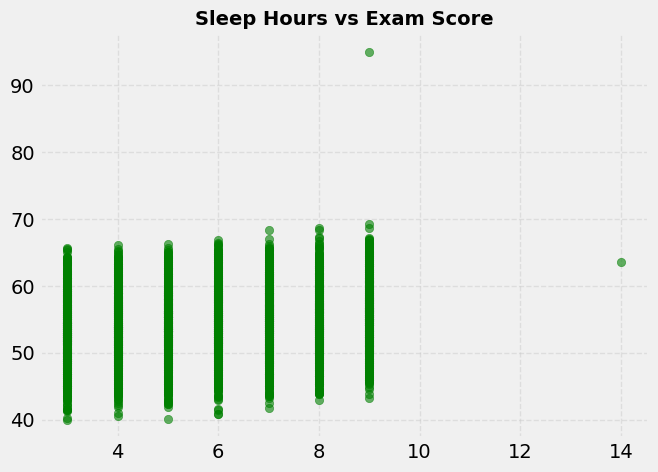

In [68]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Sleep_Hours'], 
    df['Exam_Score'], 
    color='green', 
    alpha=0.6
)

plt.title("Sleep Hours vs Exam Score", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

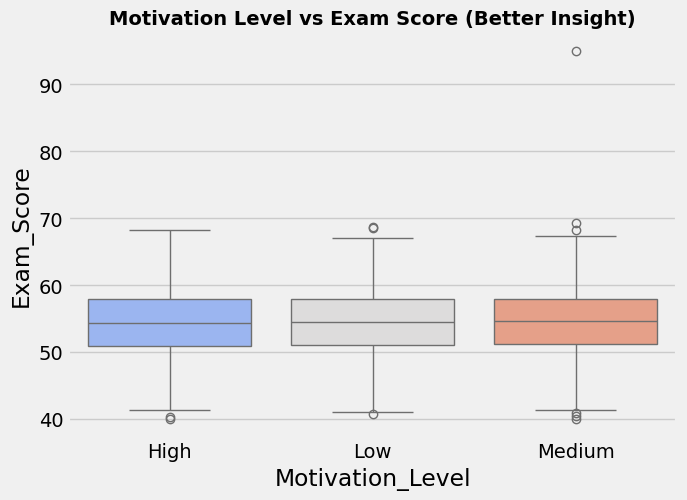

In [69]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Motivation_Level',
    y='Exam_Score',
    hue='Motivation_Level',
    data=df,
    palette='coolwarm',
    legend=False
)

plt.title("Motivation Level vs Exam Score (Better Insight)", fontsize=14, fontweight='bold')

plt.show()

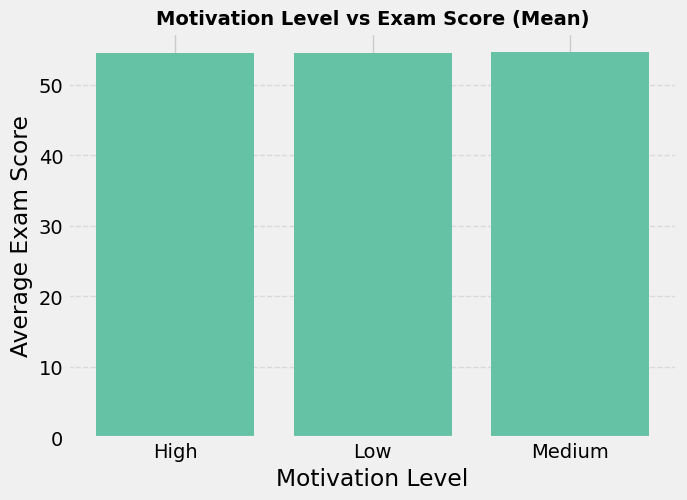

In [70]:
plt.figure(figsize=(7,5))

# Calculate mean manually
grouped = df.groupby('Motivation_Level')['Exam_Score'].mean()

# Plot
plt.bar(grouped.index, grouped.values)

plt.title("Motivation Level vs Exam Score (Mean)", fontsize=14, fontweight='bold')
plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

C:\Users\anumi\AppData\Local\Temp\ipykernel_14240\2142243962.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low, medium, high], labels=['Low', 'Medium', 'High'])


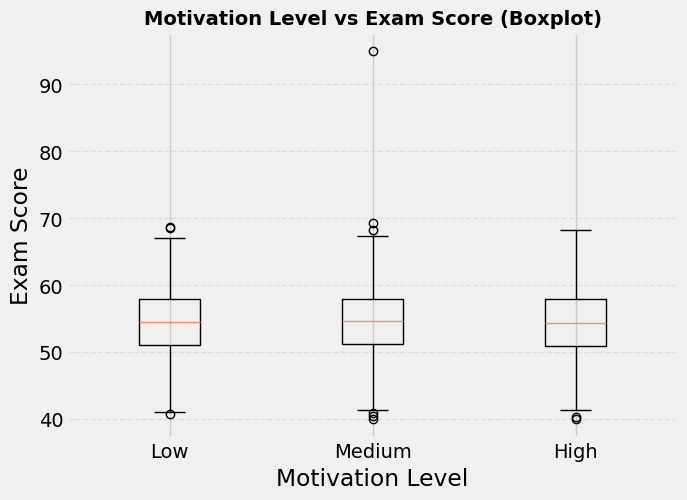

In [71]:
plt.figure(figsize=(7,5))

# Prepare data for each category
low = df[df['Motivation_Level'] == 'Low']['Exam_Score']
medium = df[df['Motivation_Level'] == 'Medium']['Exam_Score']
high = df[df['Motivation_Level'] == 'High']['Exam_Score']

plt.boxplot([low, medium, high], labels=['Low', 'Medium', 'High'])

plt.title("Motivation Level vs Exam Score (Boxplot)", fontsize=14, fontweight='bold')
plt.xlabel("Motivation Level")
plt.ylabel("Exam Score")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

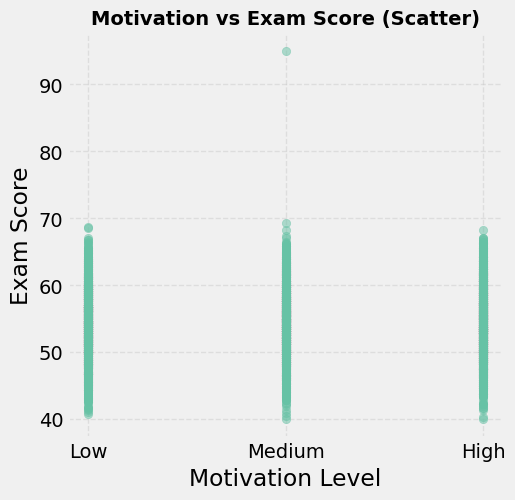

In [72]:
plt.figure(figsize=(5,5))

# Convert categories to numbers
mapping = {'Low': 1, 'Medium': 2, 'High': 3}
x = df['Motivation_Level'].map(mapping)

plt.scatter(x, df['Exam_Score'], alpha=0.5)

plt.xticks([1,2,3], ['Low', 'Medium', 'High'])

plt.title("Motivation vs Exam Score (Scatter)", fontsize=14, fontweight='bold')
plt.xlabel("Motivation Level")
plt.ylabel("Exam Score")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

<Axes: xlabel='Motivation_Level', ylabel='Exam_Score'>

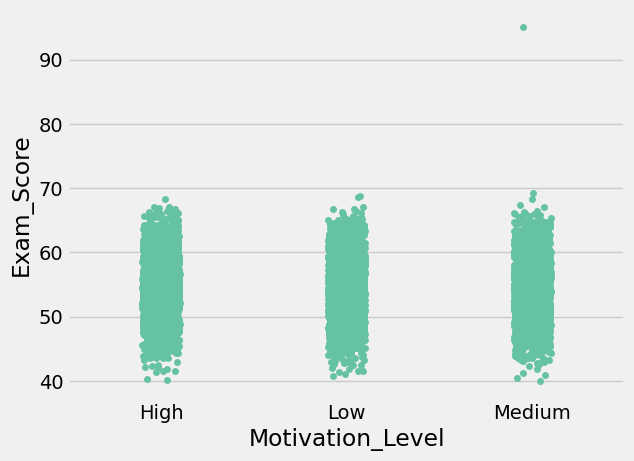

In [73]:
sns.stripplot(
    x='Motivation_Level',
    y='Exam_Score',
    data=df,
    jitter=True
)

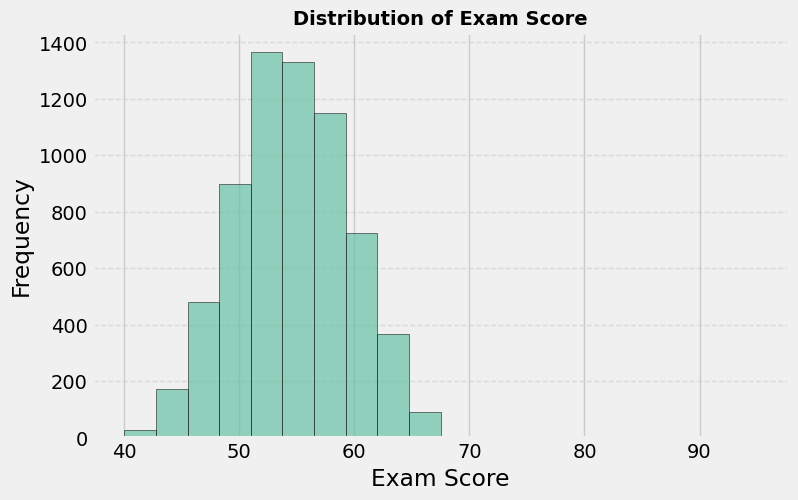

In [74]:
plt.figure(figsize=(8,5))

plt.hist(df['Exam_Score'], bins=20, edgecolor='black', alpha=0.7)

plt.title("Distribution of Exam Score", fontsize=14, fontweight='bold')
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

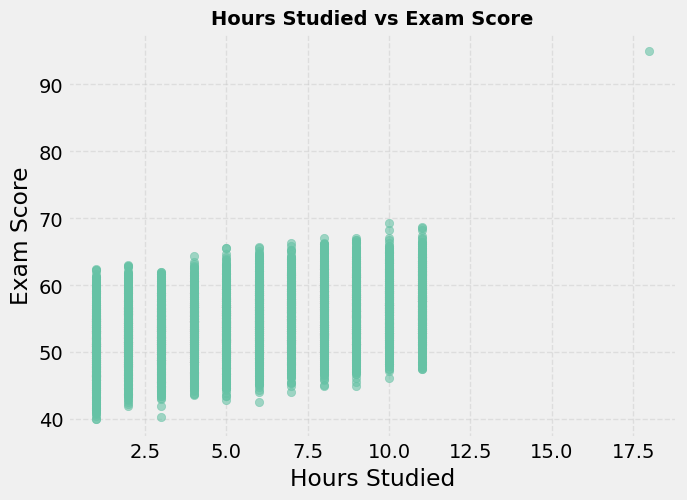

In [75]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Hours_Studied'],
    df['Exam_Score'],
    alpha=0.6
)

plt.title("Hours Studied vs Exam Score", fontsize=14, fontweight='bold')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

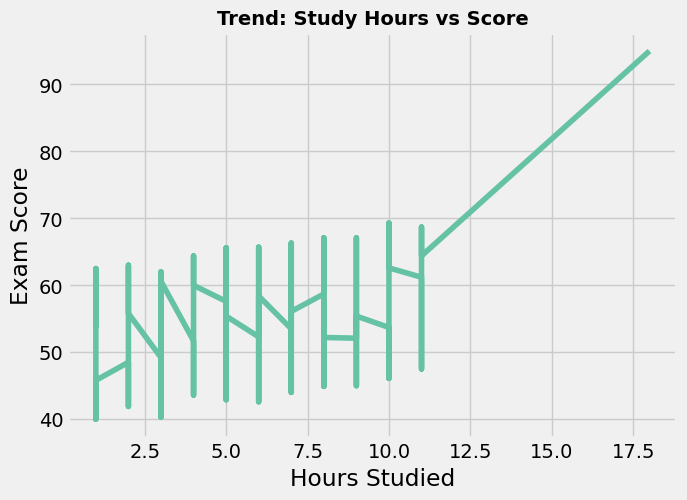

In [76]:
sorted_df = df.sort_values(by='Hours_Studied')

plt.figure(figsize=(7,5))

plt.plot(
    sorted_df['Hours_Studied'],
    sorted_df['Exam_Score']
)

plt.title("Trend: Study Hours vs Score", fontsize=14, fontweight='bold')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.grid(True)

plt.show()

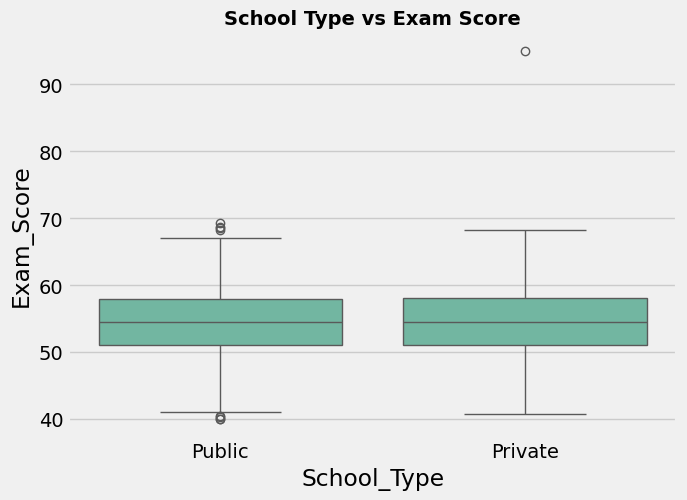

In [77]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='School_Type',
    y='Exam_Score',
    data=df
)

plt.title("School Type vs Exam Score", fontsize=14, fontweight='bold')

plt.show()

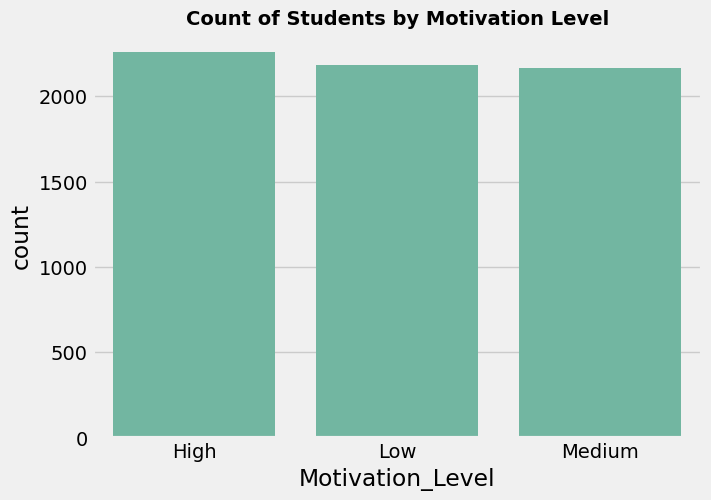

In [78]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Motivation_Level',
    data=df
)

plt.title("Count of Students by Motivation Level", fontsize=14, fontweight='bold')

plt.show()

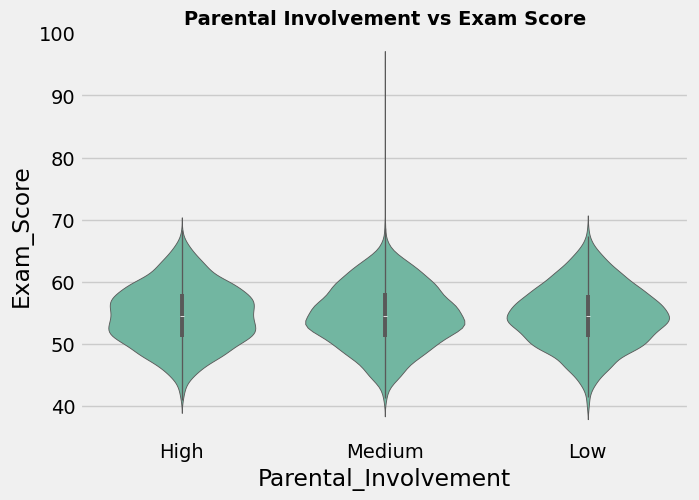

In [79]:
plt.figure(figsize=(7,5))

sns.violinplot(
    x='Parental_Involvement',
    y='Exam_Score',
    data=df,
    inner='box'   # shows median + quartiles inside
)

plt.title("Parental Involvement vs Exam Score", fontsize=14, fontweight='bold')

plt.show()

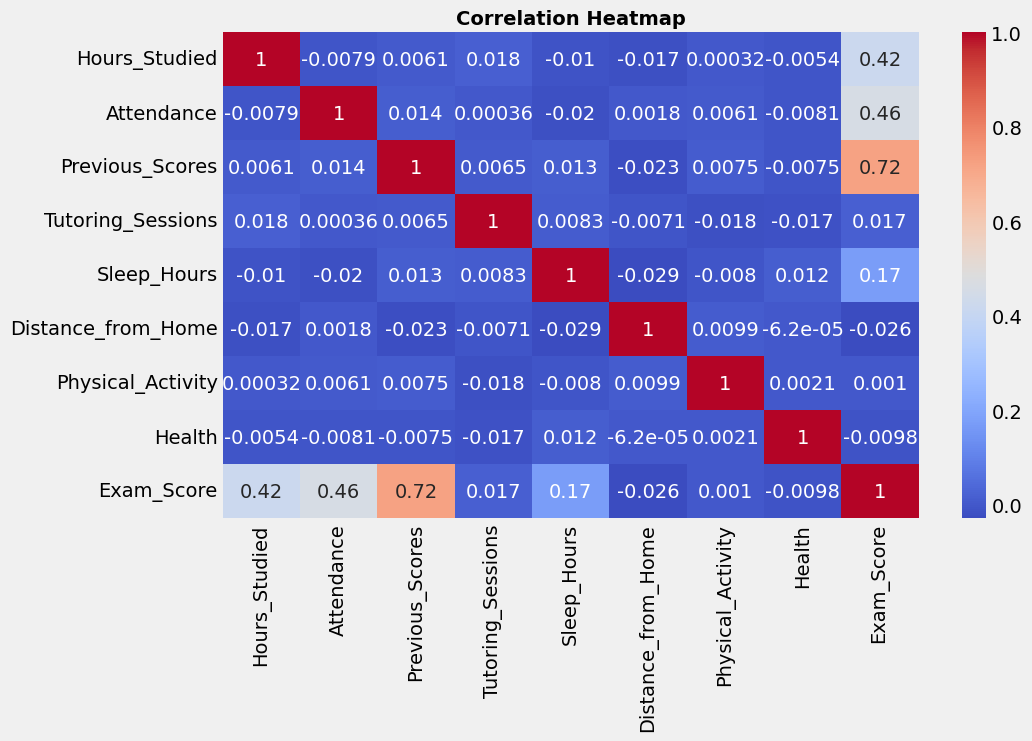

In [80]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')

plt.show()

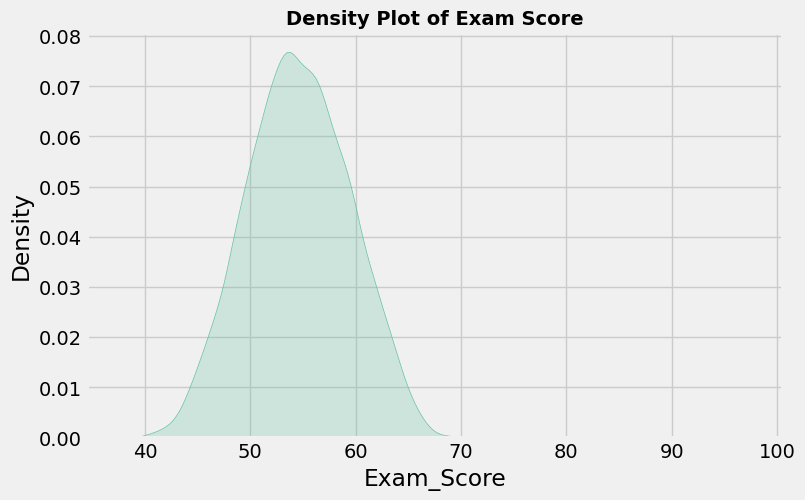

In [81]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df['Exam_Score'],
    fill=True
)

plt.title("Density Plot of Exam Score", fontsize=14, fontweight='bold')

plt.show()

In [82]:
df.corr(numeric_only=True)['Exam_Score'].sort_values(ascending=False)


Exam_Score            1.000000
Previous_Scores       0.722245
Attendance            0.460261
Hours_Studied         0.418772
Sleep_Hours           0.174170
Tutoring_Sessions     0.017338
Physical_Activity     0.000996
Health               -0.009782
Distance_from_Home   -0.026418
Name: Exam_Score, dtype: float64

In [91]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# =========================
# DEFINE X AND y
# =========================
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# =========================
# ENCODING
# =========================
X = pd.get_dummies(X, drop_first=True)

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# MODEL TRAINING
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# METRICS
# =========================
print("📊 MODEL PERFORMANCE")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))





📊 MODEL PERFORMANCE
MAE: 1.0930880942355272
MSE: 1.5809285654166765
R2 Score: 0.9332767864892172


In [92]:
# =========================
# SAVE MODEL + COLUMNS
# =========================
import joblib
joblib.dump(model, "student_model.pkl")
joblib.dump(X.columns, "model_columns.pkl")

print("\n✅ Model saved successfully!")


✅ Model saved successfully!
